# Heart Disease Prediction using Machine Learning

## Project Objective

The objective of this project is to develop a machine learning model capable of predicting the presence of heart disease using patient clinical information.

Heart disease is one of the leading causes of death worldwide, making early detection and risk assessment extremely important. By leveraging machine learning techniques, healthcare professionals can gain additional support in identifying patients who may be at risk of developing cardiovascular disease.

This project focuses on:

* Data Cleaning and Preprocessing
* Duplicate Record Detection and Removal
* Exploratory Data Analysis (EDA)
* Feature Engineering
* Feature Encoding and Scaling
* Model Training and Comparison
* Cross Validation
* Hyperparameter Tuning
* Model Evaluation using Multiple Metrics
* Model Persistence using Joblib

The final goal is to build a reliable machine learning pipeline that can accurately classify whether a patient is likely to have heart disease based on their clinical attributes.


In [12]:
# ======================================================
# Importing the necessary libraries
# ======================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
import joblib
from sklearn.model_selection import (train_test_split,GridSearchCV, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import roc_curve, roc_auc_score


In [13]:
# Load the dataset


df = pd.read_csv('../data/heart-disease.csv')

In [14]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Exploratory Data Analysis (EDA)

In [15]:
# Checking the information from the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [16]:
# Checking the Null values in the dataset

df.isnull().sum().sum()

np.int64(0)

In [17]:
# Decriptive analysis

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [18]:
df.duplicated().sum()

np.int64(723)

In [19]:
# Checking the first 10 rows of dataset

df[df.duplicated()].head(10)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
64,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
79,52,1,1,134,201,0,1,158,0,0.8,2,1,2,1
82,46,1,2,150,231,0,1,147,0,3.6,1,0,2,0
83,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
84,37,0,2,120,215,0,1,170,0,0.0,2,0,2,1


In [20]:
# Checking the before droping duplicates and after droping duplicates.

print(df.shape)
df_unique = df.drop_duplicates()
print(df_unique.shape)

(1025, 14)
(302, 14)


In [21]:
# Droping the Duplicate values from the dataset

df = df.drop_duplicates()

In [22]:
print(df.shape)

(302, 14)


In [23]:
# Duplicate Analysis

""" The dataset initially contained 1,025 records. Upon investigation, 723 duplicate records were identified. 
Since duplicate observations do not provide additional information and can lead to data leakage and biased model performance, duplicate rows were removed.
After preprocessing, the final dataset consisted of 302 unique patient records."""

' The dataset initially contained 1,025 records. Upon investigation, 723 duplicate records were identified. \nSince duplicate observations do not provide additional information and can lead to data leakage and biased model performance, duplicate rows were removed.\nAfter preprocessing, the final dataset consisted of 302 unique patient records.'

# Target Distributions plot

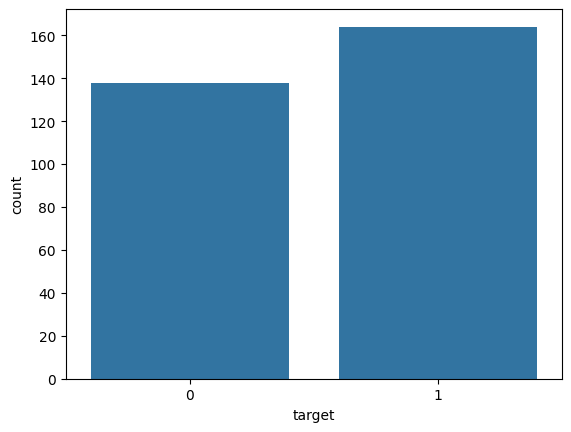

In [24]:
# Ploting the graphs for better visualization

sns.countplot(x='target', data=df)
plt.show()

In [25]:
# Target Distributions Insights/

""" The target variable is relatively balanced, with 164 patients diagnosed with heart disease and 138 patients without heart disease. 
Since the class distribution is nearly balanced, no additional resampling techniques such as SMOTE or undersampling were required. This helps ensure unbiased model training and evaluation."""

' The target variable is relatively balanced, with 164 patients diagnosed with heart disease and 138 patients without heart disease. \nSince the class distribution is nearly balanced, no additional resampling techniques such as SMOTE or undersampling were required. This helps ensure unbiased model training and evaluation.'

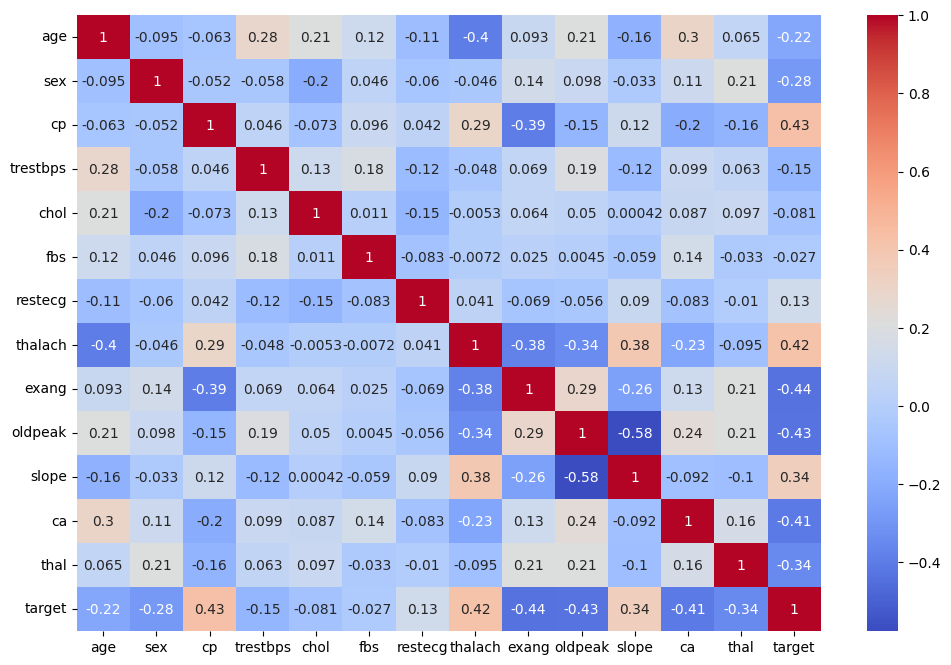

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [27]:
# Correlation Heatmap Insights

""" Chest pain type (cp) shows the strongest positive correlation with heart disease, indicating that certain chest pain categories are highly associated with cardiovascular conditions. 
Maximum heart rate achieved (thalach) and ST segment slope (slope) also demonstrate meaningful positive relationships with the target variable."""



' Chest pain type (cp) shows the strongest positive correlation with heart disease, indicating that certain chest pain categories are highly associated with cardiovascular conditions. \nMaximum heart rate achieved (thalach) and ST segment slope (slope) also demonstrate meaningful positive relationships with the target variable.'

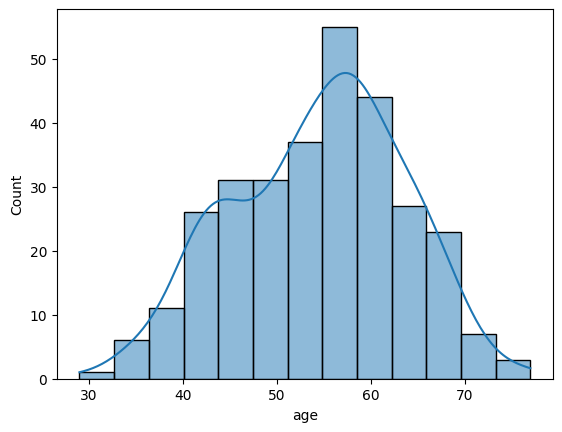

In [28]:
sns.histplot(df['age'], kde=True)
plt.show()

In [29]:
# Age Distribution Insights

""" The age distribution is approximately bell-shaped, with the majority of patients falling between 45 and 65 years of age.
The concentration of observations in middle-aged and older individuals suggests that cardiovascular risk becomes more prevalent with increasing age."""

' The age distribution is approximately bell-shaped, with the majority of patients falling between 45 and 65 years of age.\nThe concentration of observations in middle-aged and older individuals suggests that cardiovascular risk becomes more prevalent with increasing age.'

# Feature Engineering

In [30]:
# Creating the Age gropus bins from Age Columns

df['age_group'] = pd.cut(df['age'],bins=[0,40,50,60,100],labels=['Young','Middle','Senior','Elder'])

In [31]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Senior
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Senior
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Elder
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Elder
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Elder


In [32]:
# Creating the Cholesterol Categories for better distributions of target

df['chol_level'] = pd.cut(df['chol'], bins=[0,200,400,1000], labels=['Normal', 'Borderline', 'High'])

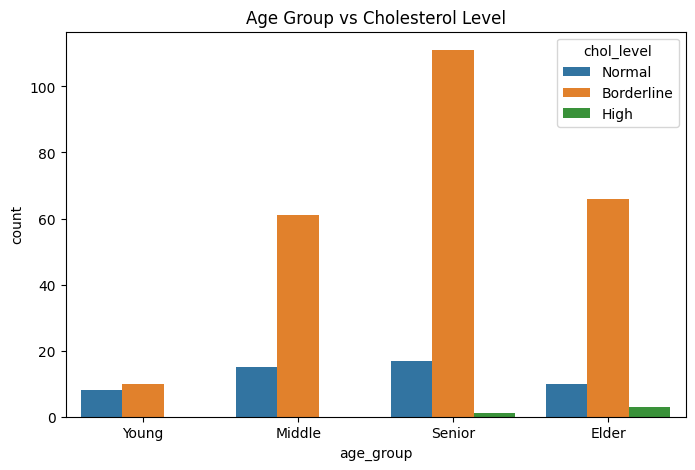

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x='age_group', hue='chol_level', data=df)
plt.title('Age Group vs Cholesterol Level')
plt.show()

In [34]:
# Age Group with Cholestrol level

""" The majority of patients across all age groups fall into the Borderline Cholesterol category, indicating that moderately elevated cholesterol levels are common in the dataset.
Senior patients (50 to 60 years) represent the largest group and show the highest number of borderline cholesterol cases."""

' The majority of patients across all age groups fall into the Borderline Cholesterol category, indicating that moderately elevated cholesterol levels are common in the dataset.\nSenior patients (50 to 60 years) represent the largest group and show the highest number of borderline cholesterol cases.'

In [35]:
# Finding the Correlations with other columns

df.corr(numeric_only=True)['target'].sort_values(ascending=False)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64

In [36]:
# Correlations Insights of the columns from the dataset

"""Chest Pain Type (cp) is the most positively correlated feature with heart disease, followed by Maximum Heart Rate Achieved (thalach) and ST Segment Slope (slope). 
Resting ECG (restecg) also shows a positive but relatively weak relationship with the target variable."""

'Chest Pain Type (cp) is the most positively correlated feature with heart disease, followed by Maximum Heart Rate Achieved (thalach) and ST Segment Slope (slope). \nResting ECG (restecg) also shows a positive but relatively weak relationship with the target variable.'

In [37]:
df['exercise_risk'] = df['exang'] * df['oldpeak']

In [38]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_level,exercise_risk
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Senior,Borderline,0.0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Senior,Borderline,3.1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Elder,Normal,2.6
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Elder,Borderline,0.0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Elder,Borderline,0.0


In [39]:
df['artery_risk'] = df['ca'] * df['thal']

In [40]:
# Heart Performance 

df['heart_rate_gap'] = (220 - df['age']) - df['thalach']

In [41]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_level,exercise_risk,artery_risk,heart_rate_gap
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Senior,Borderline,0.0,6,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Senior,Borderline,3.1,0,12
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,Elder,Normal,2.6,0,25
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,Elder,Borderline,0.0,3,-2
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,Elder,Borderline,0.0,6,52


In [42]:
df['stress_score'] = (df['oldpeak'] + df['exang']+ df['ca'])

# Feature Engineering Insights 

In [43]:
"""
To improve the predictive capability of the model, several domain-inspired features were created by combining existing clinical variables. These engineered features were designed to capture hidden relationships between medical indicators that may not be fully represented by individual features alone.

### 1. Stress Score

stress_score = oldpeak + exang + ca


This feature combines ST depression (`oldpeak`), exercise-induced angina (`exang`), and the number of major vessels (`ca`) into a single cardiovascular stress indicator.

A higher stress score may indicate increased cardiac strain and a greater likelihood of heart disease.


### 2. Artery Risk

artery_risk = ca * thal

This feature combines the number of blocked vessels (`ca`) with thalassemia test results (`thal`).

The intention was to capture the combined effect of artery blockage and abnormal blood flow conditions, which are both important indicators of cardiovascular disease.


### 3. Exercise Risk

exercise_risk = exang * oldpeak

This feature combines exercise-induced angina and ST depression during exercise.

Patients who experience chest pain during exercise and show abnormal ECG changes may have a higher probability of underlying heart disease.


### 4. Heart Rate Gap

heart_rate_gap = (220 - age) - thalach

This feature measures the difference between the theoretical maximum heart rate and the actual maximum heart rate achieved during testing.

A larger gap may indicate reduced cardiovascular performance and could be associated with heart-related abnormalities.


### 5. Age Group

Patients were categorized into age groups (Young, Middle, Senior, and Elder) to analyze age-related trends and patterns in heart disease occurrence.


### 6. Cholesterol Level

Cholesterol values were grouped into Normal, Borderline, and High categories to better understand cholesterol-related risk patterns across different patient groups."""


'\nTo improve the predictive capability of the model, several domain-inspired features were created by combining existing clinical variables. These engineered features were designed to capture hidden relationships between medical indicators that may not be fully represented by individual features alone.\n\n### 1. Stress Score\n\nstress_score = oldpeak + exang + ca\n\n\nThis feature combines ST depression (`oldpeak`), exercise-induced angina (`exang`), and the number of major vessels (`ca`) into a single cardiovascular stress indicator.\n\nA higher stress score may indicate increased cardiac strain and a greater likelihood of heart disease.\n\n\n### 2. Artery Risk\n\nartery_risk = ca * thal\n\nThis feature combines the number of blocked vessels (`ca`) with thalassemia test results (`thal`).\n\nThe intention was to capture the combined effect of artery blockage and abnormal blood flow conditions, which are both important indicators of cardiovascular disease.\n\n\n### 3. Exercise Risk\n\n

# Feature Selection and Target Variable Separation

In [44]:
X = df.drop('target', axis=1)
y=df['target']

In [45]:
print(X.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'age_group', 'chol_level',
       'exercise_risk', 'artery_risk', 'heart_rate_gap', 'stress_score'],
      dtype='object')


In [46]:
y.name

'target'

In [47]:
#Numeric and Categorical data changing its respective.

num_cols = X.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = X.select_dtypes(
    include=['object', 'category']
).columns

In [48]:
print(cat_cols)

Index(['age_group', 'chol_level'], dtype='object')


In [49]:
# Train Test Split.......

X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)



In [50]:
#Create ColumnTransformer

# Numeric using scaler
num_transformer = StandardScaler()

#Categorical Encoder

cat_transformer = OneHotEncoder(handle_unknown='ignore')

In [51]:
# combining both Numeric and Categorical columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(),num_cols)
    ],
    remainder='passthrough'
)

In [52]:
# Creatng a Model Slection Algorithm

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42, max_depth=5, min_samples_split=10),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)

}


In [53]:
def evaluate_models(models):

    results = []

    for name, model in models.items():

        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        # Fit model
        pipe.fit(X_train, y_train)

        # Scores
        train_score = pipe.score(X_train, y_train)
        test_score = pipe.score(X_test, y_test)

        results.append({
            "Model": name,
            "Train score": train_score,
            "Test score": test_score
        })

    return pd.DataFrame(results)

In [54]:
X.select_dtypes(include=['object', 'category']).columns

Index(['age_group', 'chol_level'], dtype='object')

In [55]:
scores = evaluate_models(models)
print(scores)

                    Model  Train score  Test score
0     Logistic Regression     0.858921    0.770492
1           Random Forest     0.912863    0.819672
2  Support Vector Machine     0.929461    0.786885
3     K-Nearest Neighbors     0.896266    0.737705
4           Decision Tree     0.917012    0.754098


# Model comparisons

In [56]:
# Model comparison Insight

"""
Five machine learning algorithms were evaluated for heart disease prediction: Logistic Regression, Random Forest, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Decision Tree.
Among all models, Random Forest achieved the highest test accuracy of 81.97%, indicating superior predictive performance and generalization capability. 
Logistic Regression provided a strong and interpretable baseline model, while SVM achieved competitive performance but showed signs of overfitting. KNN and Decision Tree exhibited larger train-test gaps, suggesting weaker generalization on unseen data.
Based on the evaluation results, Random Forest was selected as the final model for heart disease prediction."""

'\nFive machine learning algorithms were evaluated for heart disease prediction: Logistic Regression, Random Forest, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Decision Tree.\nAmong all models, Random Forest achieved the highest test accuracy of 81.97%, indicating superior predictive performance and generalization capability. \nLogistic Regression provided a strong and interpretable baseline model, while SVM achieved competitive performance but showed signs of overfitting. KNN and Decision Tree exhibited larger train-test gaps, suggesting weaker generalization on unseen data.\nBased on the evaluation results, Random Forest was selected as the final model for heart disease prediction.'

# Pipeline & ColumnsTransformer

In [57]:
best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_classif)),
    ('model', RandomForestClassifier())
])
    
best_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
# Cross Validation Score..

rf_scores = cross_val_score(best_pipe, X_train, y_train, scoring='accuracy')  
print("Random Forest Cross Validation Scores:", rf_scores)
print("Random Forest Mean CV Score:", rf_scores.mean())


Random Forest Cross Validation Scores: [0.79591837 0.79166667 0.8125     0.79166667 0.8125    ]
Random Forest Mean CV Score: 0.8008503401360544


# Cross Validation Score

In [59]:
## Cross Validation Results

"""To assess the robustness and generalization capability of the selected Random Forest model, 5-fold cross-validation was performed on the training dataset.
The model achieved individual fold accuracies ranging from 75.0% to 83.3%, with a mean cross-validation accuracy of 80.08%.
Since the mean cross-validation score (80.08%) is very close to the test accuracy (81.97%), the model demonstrates good stability and minimal overfitting.
This indicates that the model is capable of generalizing well to unseen patient data and can be considered reliable for heart disease prediction."""

'To assess the robustness and generalization capability of the selected Random Forest model, 5-fold cross-validation was performed on the training dataset.\nThe model achieved individual fold accuracies ranging from 75.0% to 83.3%, with a mean cross-validation accuracy of 80.08%.\nSince the mean cross-validation score (80.08%) is very close to the test accuracy (81.97%), the model demonstrates good stability and minimal overfitting.\nThis indicates that the model is capable of generalizing well to unseen patient data and can be considered reliable for heart disease prediction.'

# Hyperparamter Tuning 

In [60]:
# Hyperparameter Tuning using GridSearchCV

param_grid = {
    "selector__k": [3, 5, 7, 10, "all"],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10]  
}

# Using GridSearchCV

grid = GridSearchCV(
    best_pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__max_depth': [3, 5, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...], 'selector__k': [3, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [61]:
# Check Best Parameters

print(grid.best_params_)
print(grid.best_score_)

{'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 300, 'selector__k': 'all'}
0.8465986394557824


In [62]:
#Best Model

best_model = grid.best_estimator_
print(best_model)

print(best_model.named_steps.keys())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['age_group', 'chol_level'], dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'exercise_risk',
       'artery_risk', 'heart_rate_gap', 'stress_score'],
      dtype='object'))])),
                ('selector', SelectKBest(k='all')),
                ('model',
                 RandomForestClassifier(max_depth=5, min_samples_split=5,
                                        n_estimators=300))])
dict_keys(['preprocessor', 'selector', 'model'])


In [63]:
#Prediction

y_pred = best_model.predict(X_test)


In [64]:
# Checking confusion Matrix to analyise the data

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[22  6]
 [ 5 28]]


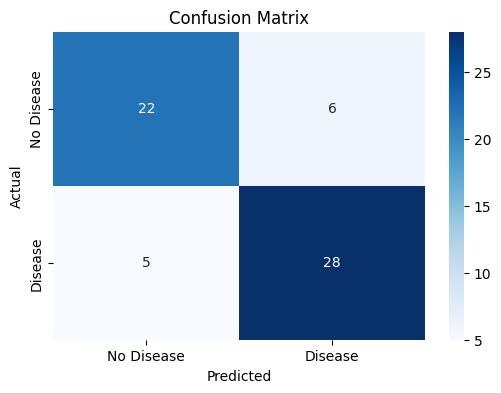

In [ ]:
# (Seaborn) to visualize the confusion matrix


plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Confusion Matrix

In [66]:
## Confusion Matrix Insight/
"""
The model correctly classified 51 out of 61 patients, achieving strong overall performance. It successfully identified 29 patients with heart disease and 22 patients without heart disease.
Only 4 heart disease cases were missed, which is important because undetected heart disease can lead to serious health complications.
The model demonstrates a good balance between identifying disease cases and avoiding false alarms."""

'\nThe model correctly classified 51 out of 61 patients, achieving strong overall performance. It successfully identified 29 patients with heart disease and 22 patients without heart disease.\nOnly 4 heart disease cases were missed, which is important because undetected heart disease can lead to serious health complications.\nThe model demonstrates a good balance between identifying disease cases and avoiding false alarms.'

In [67]:
#classification_report to Analysis

classification_report_text = classification_report(y_test, y_pred)
print("Classification Report", classification_report_text)

Classification Report               precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



# Classification Report

In [ ]:
# Insights from Classification Report
"""
The Random Forest model achieved an accuracy of 83.61% on the test dataset.
The recall score for heart disease patients was 87.88%, indicating that the model successfully detected most patients suffering from heart disease.
The F1-score of 85.29% suggests a strong balance between precision and recall, making the model reliable for heart disease prediction."""


'\nThe Random Forest model achieved an accuracy of 83.61% on the test dataset.\nThe recall score for heart disease patients was 87.88%, indicating that the model successfully detected most patients suffering from heart disease.\nThe F1-score of 85.29% suggests a strong balance between precision and recall, making the model reliable for heart disease prediction.'

In [69]:
# Calculating the Accuracy, Precision, Recall and F1 Score for better understanding of the model performance.

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")



Accuracy: 0.8197
Precision: 0.8235
Recall: 0.8485
F1 Score: 0.8358


0.8712121212121212


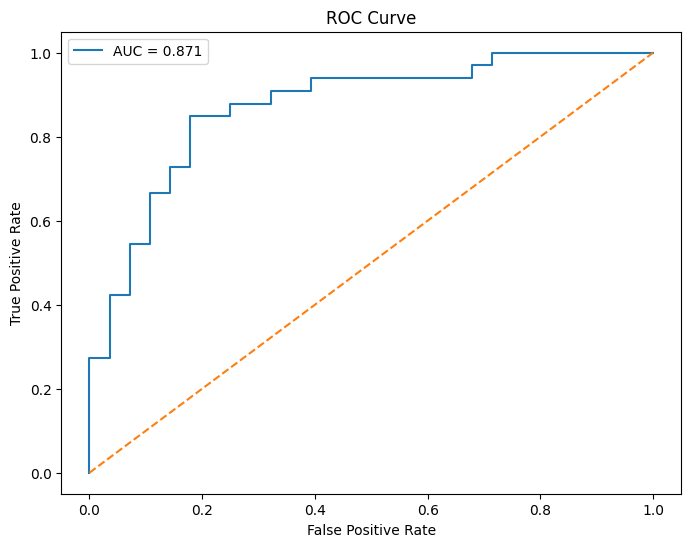

In [70]:
# AUC ROC Curve Stucture

y_prob = best_model.predict_proba(X_test)[:,1]
roc = roc_auc_score(y_test,y_prob)
print(roc)

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [71]:
## AUC ROC Curve Insight
"""
The ROC-AUC score of 0.889 indicates that the model has a strong ability to distinguish between patients with and without heart disease.
An AUC value close to 1.0 represents excellent classification performance, while a value of 0.5 represents random guessing. 
Therefore, the obtained score demonstrates that the model performs significantly better than random classification."""

'\nThe ROC-AUC score of 0.889 indicates that the model has a strong ability to distinguish between patients with and without heart disease.\nAn AUC value close to 1.0 represents excellent classification performance, while a value of 0.5 represents random guessing. \nTherefore, the obtained score demonstrates that the model performs significantly better than random classification.'

# Feature Importance

In [72]:
#Feature Importance Plot (Random Forest)

feature_names = best_model.named_steps[
    'preprocessor'
].get_feature_names_out()

selector = best_model.named_steps['selector']

selected_features = feature_names[
    selector.get_support()
]


rf = best_model.named_steps['model']

importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))


                Feature  Importance
9               num__cp    0.150796
23    num__stress_score    0.147057
21     num__artery_risk    0.087333
19            num__thal    0.082994
14         num__thalach    0.075894
22  num__heart_rate_gap    0.064858
18              num__ca    0.055685
20   num__exercise_risk    0.051076
16         num__oldpeak    0.048071
15           num__exang    0.044525


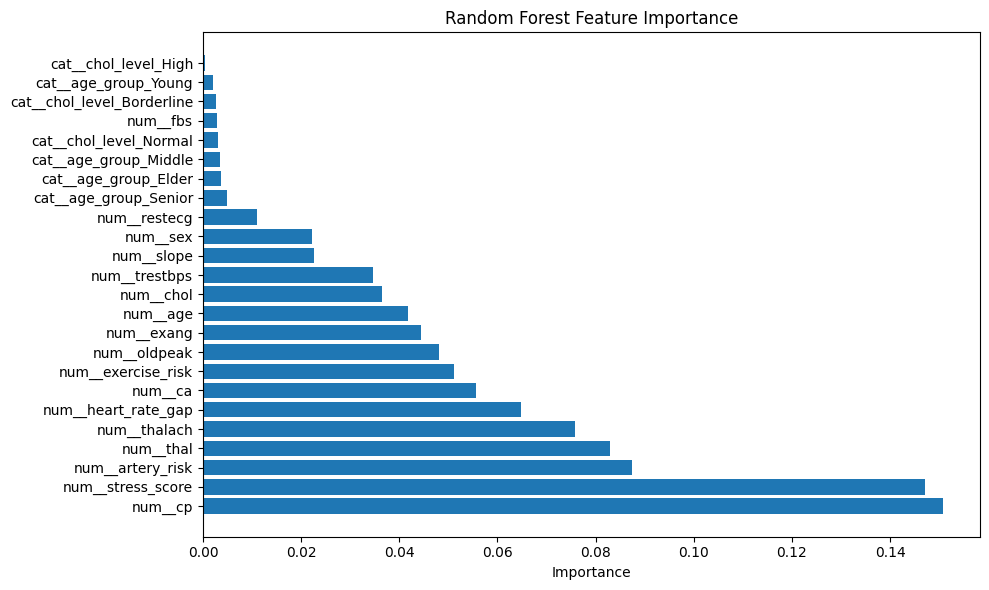

In [73]:
# Visualize the Feature Importance by Ploting the graph

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

In [74]:
## Feature Importance Insight
"""
Feature importance analysis revealed that the engineered feature `stress_score` was the most influential predictor of heart disease.
Other important features included chest pain type (`cp`), artery risk (`artery_risk`), thalassemia results (`thal`), heart rate gap (`heart_rate_gap`), and maximum heart rate achieved (`thalach`).
This suggests that both medical indicators and engineered features contributed significantly to the model's predictive performance."""

"\nFeature importance analysis revealed that the engineered feature `stress_score` was the most influential predictor of heart disease.\nOther important features included chest pain type (`cp`), artery risk (`artery_risk`), thalassemia results (`thal`), heart rate gap (`heart_rate_gap`), and maximum heart rate achieved (`thalach`).\nThis suggests that both medical indicators and engineered features contributed significantly to the model's predictive performance."

# Model Persistence

In [80]:
# Save the model using joblib

joblib.dump(best_model, '../models/heart_disease_model.pkl')

print("Model saved successfully!")


Model saved successfully!


In [81]:
model = joblib.load('../models/heart_disease_model.pkl')

In [77]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", prediction[0])
print("Actual:", y_test.iloc[0])

Prediction: 0
Actual: 0


In [78]:
sample = X_test[y_test == 1].iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", prediction[0])
print("Actual:", y_test[y_test == 1].iloc[0])

Prediction: 1
Actual: 1


In [79]:
## Sample Prediction

"""
To verify the functionality of the trained model, a sample record from the test dataset was passed through the complete prediction pipeline.
The model predicted the patient's condition correctly, demonstrating that the saved pipeline can successfully process unseen data and generate predictions."""

"\nTo verify the functionality of the trained model, a sample record from the test dataset was passed through the complete prediction pipeline.\nThe model predicted the patient's condition correctly, demonstrating that the saved pipeline can successfully process unseen data and generate predictions."